In [1]:
from transformers import MBartForConditionalGeneration, MBart50TokenizerFast
import re
import torch

tokenizer = MBart50TokenizerFast.from_pretrained("facebook/mbart-large-50-many-to-many-mmt")
model = MBartForConditionalGeneration.from_pretrained("./checkpoint-17000")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

tokenizer.src_lang = "ne_XX"
tokenizer.tgt_lang = "en_XX"

c:\NLTTA\NLTTA\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [87]:
def pre_process(text):
        text = ">>ne<< " + text
        text = text.lower()
        text = re.sub(r'[^\w\s]', '', text)
        text = re.sub(r'\s+', ' ', text).strip()  
        
        return text

In [3]:
import re

def remove_word_prefixes(text, prefixes):
    # Join all prefixes into a regex pattern (escaped), each followed by a word boundary
    pattern = r'^(' + '|'.join(re.escape(p) for p in prefixes) + r')\b\s*'
    return re.sub(pattern, '', text)

In [4]:
def translate(text):
    inputs = tokenizer(pre_process(text), return_tensors="pt")
    generated = model.generate(
        **inputs,
        forced_bos_token_id=tokenizer.lang_code_to_id["en_XX"],
        max_length=128,
        num_beams=5
    )

    return remove_word_prefixes(str(tokenizer.decode(generated[0], skip_special_tokens=True)), ['e', 'ne'])
                

In [123]:
translate("tah k garne?")

'and what to do'

In [ ]:
translate("samachar anusar, bhukampa ko kendra kathmandu ma ho")

'according to the news the center of earthquake is in kathmandu'

In [11]:
from nltk.translate.bleu_score import sentence_bleu, corpus_bleu, SmoothingFunction
from bert_score import score



In [53]:
print(references[16])
print(roman_nepali_sentences[-2])

print(len(references))
print(len(roman_nepali_sentences))

the earthquake caused major damage
yo prashikshan ek hapta samma chalne cha
36
36


# **NLTTA** 630M

In [74]:

roman_nepali_sentences = [
    "vidharthi ko aandolan",
    "yo kitab ramro cha",
    "ma school janchu",
    "samsad ko baithaak",
    "hami khelna janchau",
    "maile khana khaye",
    "yo ghar dherai thulo cha",
    "tyo manche mero saathi ho",
    "uniharu kheliraheka chan",
    "ma nepali ho",
    "timro ghar ramro cha",
    "unko naam anil ho",
    "hami school ganchau",
    "tyo film malaai dherai manparcha",
    "saarkaar le naya niti ghoshana gareko cha",
    "rajnitik paristhiti badalne cha",
    "bhukampa le dherai chaati gareko cha",
    "chimekhi desh sanga sambandha jhan ramro bhayo",
    "sainik haaru prashikshan ma chan",
    "nayaa kanun samsad bata pass bhayeko cha",
    "udyog haaru le aarthiik pragati gareka chan",
    "mantri sabai le sammelan ma vag liye",
    "shikshak haru le hartal ko ghoshana gare",
    "tyaha bijuli aaeko chaina",
    "maile tyesto kura kahile pani socheko thiena",
    "yo samasya ko samadhan chhito garnu parchha",
    "hami bholi sabha ma janchau",
    "yo radio samachar prastut gardai cha",
    "karyakram thulo samuday ko lagi aayojit bhayeko ho",
    "durbhagyabash, usto durghatna bhayo",
    "manavadhikar ko ullanghan bhayeko cha",
    "samachar anusar, bhukampa ko kendra kathmandu ma ho",
    "yo prasna dherai jatil cha",
    "chimeki le sahayog garne pratigya gare",
    "yo prashikshan ek hapta samma chalne cha",
    "sena le sima surakshit gareko cha"
]

references = [
    "students movement",
    "this book is good",
    "i go to school",
    "meeting of parliament",
    "we go to play",
    "i ate food",
    "this house is very big",
    "that person is my friend",
    "they are playing",
    "i am Nepali",
    "your house is nice",
    "his name is Anil",
    "we go to school",
    "i like that movie very much",
    "the government has announced a new policy",
    "the political situation is going to change",
    "the earthquake caused major damage",
    "relations with neighboring countries have strengthened",
    "soldiers are in training",
    "the new law was approved by the parliament",
    "industries have made economic progress",
    "the ministers participated in the conference",
    "the teachers have announced a strike",
    "there is no electricity there",
    "I had never thought of such a thing",
    "this problem must be solved quickly",
    "we are going to the assembly tomorrow",
    "this radio is presenting the news",
    "the program was organized for a large community",
    "unfortunately, such an accident happened",
    "a violation of human rights has occurred",
    "according to the news, the earthquake's epicenter is Kathmandu",
    "this question is very complicated",
    "the neighbor promised to help",
    "this training will continue for one week",
    "the army has secured the border",
]

hypotheses = [
]

for text in roman_nepali_sentences:
    translated_text = translate(text)
    hypotheses.append(translated_text)

tokenized_references = [[ref.split()] for ref in references]  
tokenized_hypotheses = [hyp.split() for hyp in hypotheses]    

smoothing_fn = SmoothingFunction().method1

#corpus-level BLEU
bleu_score = corpus_bleu(tokenized_references, tokenized_hypotheses, smoothing_function=smoothing_fn)
print(f"Corpus BLEU Score: {bleu_score * 100:.2f}")

#sentence-level BLEU scores
print("\nSentence-level BLEU scores:")
for i, (ref, hyp) in enumerate(zip(tokenized_references, tokenized_hypotheses)):
    score_sentence = sentence_bleu(ref, hyp, smoothing_function=smoothing_fn)
    print(f"Sentence {i+1}: {score_sentence * 100:.2f}")


Corpus BLEU Score: 39.84

Sentence-level BLEU scores:
Sentence 1: 31.62
Sentence 2: 100.00
Sentence 3: 100.00
Sentence 4: 56.23
Sentence 5: 100.00
Sentence 6: 56.23
Sentence 7: 66.87
Sentence 8: 28.57
Sentence 9: 56.23
Sentence 10: 24.03
Sentence 11: 39.76
Sentence 12: 39.76
Sentence 13: 100.00
Sentence 14: 100.00
Sentence 15: 100.00
Sentence 16: 17.10
Sentence 17: 7.73
Sentence 18: 54.75
Sentence 19: 100.00
Sentence 20: 6.85
Sentence 21: 26.59
Sentence 22: 16.35
Sentence 23: 4.18
Sentence 24: 77.88
Sentence 25: 14.59
Sentence 26: 6.50
Sentence 27: 8.09
Sentence 28: 23.39
Sentence 29: 14.77
Sentence 30: 0.00
Sentence 31: 3.46
Sentence 32: 10.60
Sentence 33: 28.57
Sentence 34: 13.23
Sentence 35: 17.29
Sentence 36: 100.00


In [48]:

P, R, F1 = score(hypotheses, references, lang="en", verbose=True)
print(f"Average BERTScore F1: {F1.mean().item():.4f}")


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


calculating scores...
computing bert embedding.


100%|██████████| 1/1 [00:01<00:00,  1.53s/it]


computing greedy matching.


100%|██████████| 1/1 [00:00<00:00, 216.05it/s]

done in 1.54 seconds, 23.41 sentences/sec
Average BERTScore F1: 0.9613


# **Gemini** Gemini 2.5 Flash (since it is the most used model for new and free users)

In [47]:
gemini_hypotheses = [
    "student protest",
    "this book is good",
    "I go to school",
    "parliamentary meeting",
    "we go to play",
    "I ate food",
    "this house is very big",
    "that person is my friend",
    "they are playing",
    "I am Nepali",
    "your house is good",
    "his name is Anil",
    "we go to school",
    "I like that movie very much",
    "the government has announced a new policy",
    "the political situation will change",
    "the earthquake has caused a lot of damage",
    "relations with neighboring countries have improved",
    "soldiers are in training",
    "the new law has been passed by the parliament",
    "industries have made economic progress",
    "all ministers participated in the conference",
    "teachers have declared a strike",
    "there is no electricity",
    "I had never thought such a thing",
    "this problem needs to be solved quickly",
    "we will go to the meeting tomorrow",
    "this radio is presenting the news",
    "the program was organized for a large community",
    "unfortunately, such an accident happened",
    "human rights have been violated",
    "according to the news, the epicenter of the earthquake is in Kathmandu",
    "this question is very complex",
    "the neighbor promised to cooperate",
    "this training will last for one week",
    "the army has secured the border"
]

tokenized_gemini_hypotheses = [hyp.lower().split() for hyp in gemini_hypotheses]    

bleu_score = corpus_bleu(tokenized_references, tokenized_gemini_hypotheses, smoothing_function=smoothing_fn)
print(f"Corpus BLEU Score: {bleu_score * 100:.2f}")


P, R, F1 = score(gemini_hypotheses, references, lang="en", verbose=True)
print(f"Average BERTScore F1: {F1.mean().item():.4f}")


Corpus BLEU Score: 62.43


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


calculating scores...
computing bert embedding.


100%|██████████| 1/1 [00:01<00:00,  1.41s/it]


computing greedy matching.


100%|██████████| 1/1 [00:00<00:00, 248.43it/s]

done in 1.42 seconds, 25.39 sentences/sec
Average BERTScore F1: 0.9810


# **Deepseek R1** DeepSeek-V3 671B

In [ ]:
deepseek_hypotheses = [
    "Student protest/movement",
    "This book is good",
    "I go to school",
    "Parliament meeting/session",
    "We are going to play",
    "I ate food",
    "This house is very big",
    "That person is my friend",
    "They are playing",
    "I am Nepali",
    "Your house is nice",
    "His/Her name is Anil",
    "We go to school together",
    "I really like that movie",
    "The government has announced a new policy",
    "The political situation is changing",
    "The earthquake caused a lot of destruction",
    "Relations with the neighboring country have improved",
    "The soldiers are in training",
    "The new law has been passed by parliament",
    "Industries have made economic progress",
    "All ministers participated in the conference",
    "Teachers have announced a strike",
    "There is no electricity there",
    "I never thought of such a thing",
    "This problem needs to be solved quickly",
    "We are going to the assembly tomorrow",
    "This radio is presenting news",
    "The program was organized for the large community",
    "Unfortunately, that accident happened",
    "Human rights have been violated",
    "According to news, the earthquake's epicenter is in Kathmandu",
    "This question is very complex",
    "The neighbor promised to help",
    "This training will last for one week",
    "The army has secured the border"
]

tokenized_deepseek_hypotheses = [hyp.lower().split() for hyp in deepseek_hypotheses]    

bleu_score = corpus_bleu(tokenized_references, tokenized_deepseek_hypotheses, smoothing_function=smoothing_fn)
print(f"Corpus BLEU Score: {bleu_score * 100:.2f}")

P, R, F1 = score(deepseek_hypotheses, references, lang="en", verbose=True)
print(f"Average BERTScore F1: {F1.mean().item():.4f}")


Corpus BLEU Score: 61.27


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


calculating scores...
computing bert embedding.


100%|██████████| 2/2 [00:01<00:00,  1.05it/s]


computing greedy matching.


100%|██████████| 1/1 [00:00<00:00, 220.85it/s]


done in 1.92 seconds, 18.78 sentences/sec
Average BERTScore F1: 0.9733


# **ChatGpt** GPT-4o(1.8T)

In [13]:
chatgpt_hypotheses = [
    "Students' movement",
    "This book is good",
    "I go to school",
    "Parliament meeting",
    "We go to play",
    "I ate food",
    "This house is very big",
    "That person is my friend",
    "They are playing",
    "I am Nepali",
    "Your house is nice",
    "His name is Anil",
    "We go to school",
    "I like that movie very much",
    "The government has announced a new policy",
    "The political situation will change",
    "The earthquake has caused a lot of damage",
    "Relations with neighboring countries improved",
    "Soldiers are in training",
    "A new law has been passed by parliament",
    "Industries have made economic progress",
    "All ministers participated in the conference",
    "The teachers have announced a strike",
    "There is no electricity there",
    "I had never thought such a thing",
    "This problem needs to be solved quickly",
    "We will go to the meeting tomorrow",
    "This radio is presenting the news",
    "The program has been organized for a large community",
    "Unfortunately, such an accident happened",
    "There has been a violation of human rights",
    "According to the news, the epicenter of the earthquake is Kathmandu",
    "This question is very complicated",
    "The neighbor promised to help",
    "He has an interest in material science",
    "This training will last for a week",
    "The army has secured the border"
]

tokenized_chatgpt_hypotheses = [hyp.lower().split() for hyp in chatgpt_hypotheses]    

bleu_score = corpus_bleu(tokenized_references, tokenized_chatgpt_hypotheses, smoothing_function=smoothing_fn)
print(f"Corpus BLEU Score: {bleu_score * 100:.2f}")


P, R, F1 = score(chatgpt_hypotheses, references, lang="en", verbose=True)
print(f"Average BERTScore F1: {F1.mean().item():.4f}")


Corpus BLEU Score: 63.11


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


calculating scores...
computing bert embedding.


100%|██████████| 2/2 [00:01<00:00,  1.14it/s]


computing greedy matching.


100%|██████████| 1/1 [00:00<00:00, 200.26it/s]

done in 1.77 seconds, 20.91 sentences/sec
Average BERTScore F1: 0.9842


# **LLAMA 2** (Open source Model) 7B parameters

In [76]:
print(len(llama_hypotheses))
print(len(references))


31
36


In [70]:
print(llama_hypotheses)
print(references)


['Uprising for justice', 'I have read that book', 'I go to school', 'We sit together', "Let's play", 'I eat rice', 'He has a big house', 'You are my friend', 'We will make a new plan', 'The situation is changing rapidly', 'We must act quickly', 'We will overcome this obstacle', 'Nepal is our country', 'Our home is beautiful', 'His name is Anil', 'We go to school together', 'They made a movie about us', 'New policies are being implemented', 'We will organize a protest rally', 'We will not be silenced', 'We want equality', 'We will stand up for our rights', 'We will fight against injustice', 'We will protect ourselves', 'We will not be oppressed', 'We will rise above', 'We will unite', 'We will make a difference', 'We will bring change', 'We will not be defeated', 'We will triumph over adversity', 'We will never give up', 'We will always resist', 'We will never be silenced', 'We will speak out', 'We will raise our voices', 'We will demand justice', 'We will take action', 'We will make a 

In [75]:
llama_hypotheses = [
    "Uprising for justice",
   "I have read that book",
   "I go to school",
   "We sit together",
   "Let's play",
   "I eat rice",
   "He has a big house",
   "You are my friend",
   "We will make a new plan",
   "Nepal is our country",
   "Our home is beautiful",
   "His name is Anil",
   "We go to school together",
   "They made a movie about us",
   "New policies are being implemented",
   "We should work together towards economic growth.",
    "The ministers met.",
    "Teachers went on strike.",
    "No electricity supply.",
     "I don't have enough money to buy food.",
     "It is our responsibility to solve problems.",
     "We will make slow but steady progress.",
     "Radio news bulletins are informative.",
     "Big plans are being made for the future.",
     "Sorry, we are facing numerous challenges.",
     "Human rights are crucial.",
     "As per the latest news, there is a problem in Kathmandu.",
      "The issue is complicated.",
      "Let us come together to help each other.",
      "This training is extremely beneficial.",
      "Our security forces are working hard to keep us safe."
   
]


tokenized_llama_hypotheses = [hyp.lower().split() for hyp in llama_hypotheses]    

bleu_score = corpus_bleu(tokenized_references, tokenized_llama_hypotheses, smoothing_function=smoothing_fn)
print(f"Corpus BLEU Score: {bleu_score * 100:.2f}")


P, R, F1 = score(llama_hypotheses, references, lang="en", verbose=True)
print(f"Average BERTScore F1: {F1.mean().item():.4f}")


AssertionError: The number of hypotheses and their reference(s) should be the same 

# **LLAM 4**(Maverick: 400Billion Parameters, Meta Largest capable AI)

In [50]:
llama4_hypotheses = [
    "Student movement",
    "This book is good",
    "I go to school",
    "Parliament session",
    "We go to play",
    "I ate food",
    "This house is very big",
    "That person is my friend",
    "They are playing",
    "I am Nepali",
    "Your house is good",
    "His name is Anil",
    "We go to school",
    "I like that movie a lot",
    "The government has announced a new policy",
    "The political situation is changing",
    "The earthquake caused a lot of damage",
    "Relations with China have improved",
    "Soldiers are in training",
    "A new law has been passed by parliament",
    "Industries have made economic progress",
    "All ministers spoke at the conference",
    "Teachers have declared a strike",
    "There is no electricity there",
    "I had never thought of such a thing",
    "This problem needs to be solved quickly",
    "We are going to the meeting tomorrow",
    "This radio is presenting news",
    "The program is organized for the whole community",
    "Unfortunately, such an accident happened",
    "Human rights have been violated",
    "According to the news, the earthquake's center was in Kathmandu",
    "This question is very complex",
    "China has promised to cooperate",
    "This training will continue for a week",
    "The army has secured the border"
]


tokenized_llama4_hypotheses = [hyp.lower().split() for hyp in llama4_hypotheses]    

bleu_score = corpus_bleu(tokenized_references, tokenized_llama4_hypotheses, smoothing_function=smoothing_fn)
print(f"Corpus BLEU Score: {bleu_score * 100:.2f}")


P, R, F1 = score(llama4_hypotheses, references, lang="en", verbose=True)
print(f"Average BERTScore F1: {F1.mean().item():.4f}")


Corpus BLEU Score: 57.33


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


calculating scores...
computing bert embedding.


100%|██████████| 2/2 [00:01<00:00,  1.08it/s]


computing greedy matching.


100%|██████████| 1/1 [00:00<00:00, 248.82it/s]

done in 1.87 seconds, 19.27 sentences/sec
Average BERTScore F1: 0.9781


# Plot

In [55]:
bleu_scores = {
    "Deepseek V3 (671B)": 61.27,
    "ChatGPT (1.8T)": 63.11,
    "LLAMA 4 (400B)": 57.33,
    "Gemini 2.5 Flash(No official Parameter Count)": 62.83,
    "NLTTA (630M)": 39.84
}
bert_scores = {
    "Deepseek V3 (671B)": 0.9733,
    "ChatGPT (1.8T)": 0.9842,
    "LLAMA 4 (400B)": 0.9781,
    "Gemini 2.5 Flash(No official Parameter Count)": 0.9810,
    "NLTTA (630M)": 0.9613
}

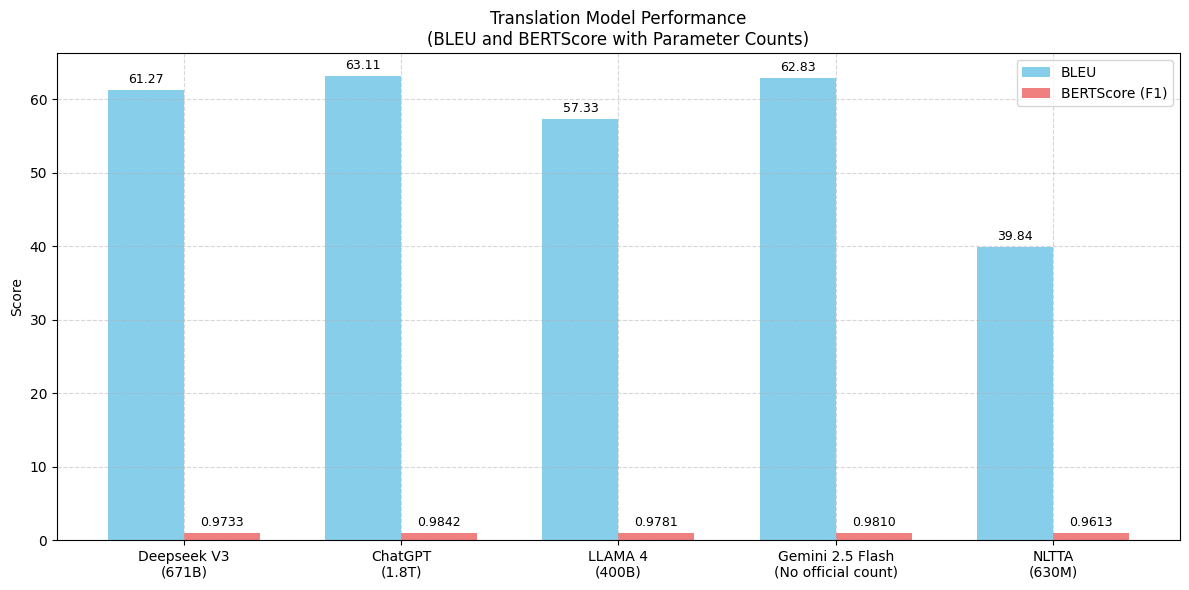

In [80]:
import matplotlib.pyplot as plt
import numpy as np

# Model names with parameter counts
models = [
    "Deepseek V3\n(671B)", 
    "ChatGPT\n(1.8T)", 
    "LLAMA 4\n(400B)", 
    "Gemini 2.5 Flash\n(No official count)", 
    "NLTTA\n(630M)"
]

# Scores
bleu_scores = [61.27, 63.11, 57.33, 62.83, 39.84]
bert_scores = [0.9733, 0.9842, 0.9781, 0.9810, 0.9613]

# Bar positions
x = np.arange(len(models))
width = 0.35

# Create plot
fig, ax = plt.subplots(figsize=(12, 6))

# Plot BLEU and BERTScore bars
bleu_bars = ax.bar(x - width/2, bleu_scores, width, label='BLEU', color='skyblue')
bert_bars = ax.bar(x + width/2, bert_scores, width, label='BERTScore (F1)', color='lightcoral')

# Add labels and title
ax.set_ylabel('Score')
ax.set_title('Translation Model Performance\n(BLEU and BERTScore with Parameter Counts)')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=10)
ax.legend()

# Annotate bars with scores
def annotate_bars(bars, decimals=2):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.{decimals}f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

annotate_bars(bleu_bars)
annotate_bars(bert_bars, decimals=4)

# Style
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


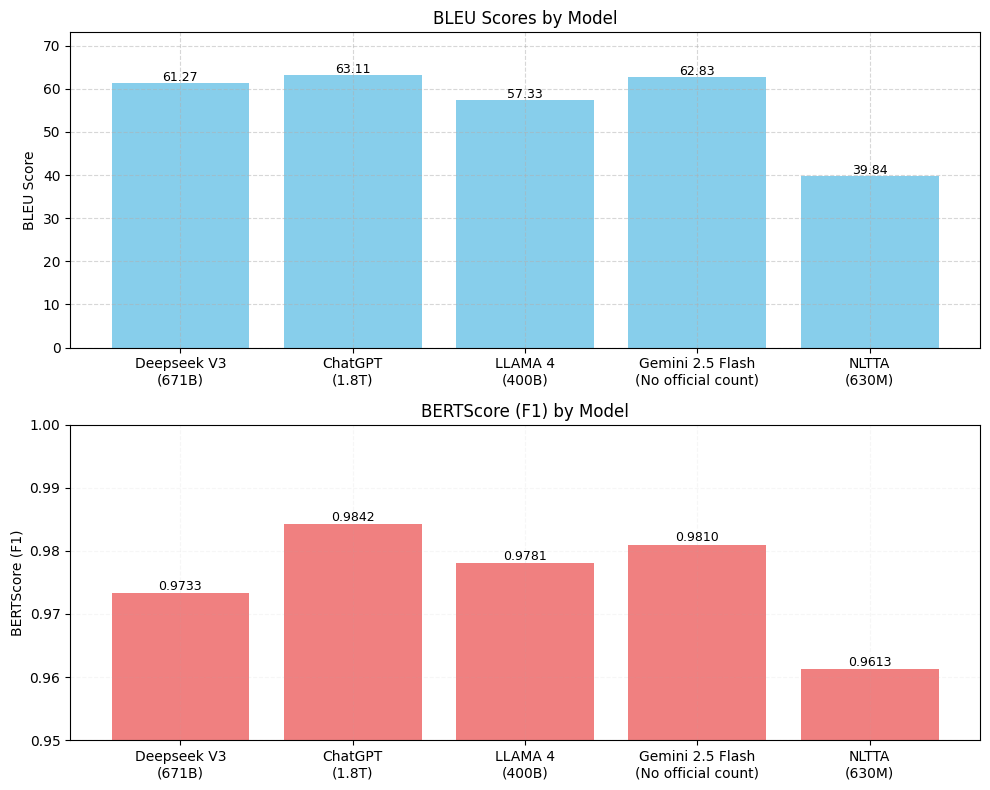

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = [
    "Deepseek V3\n(671B)", 
    "ChatGPT\n(1.8T)", 
    "LLAMA 4\n(400B)", 
    "Gemini 2.5 Flash\n(No official count)", 
    "NLTTA\n(630M)"
]
bleu_scores = [61.27, 63.11, 57.33, 62.83, 39.84]
bert_scores = [0.9733, 0.9842, 0.9781, 0.9810, 0.9613]

x = np.arange(len(models)) 

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.bar(models, bleu_scores, color='skyblue')
ax1.set_title("BLEU Scores by Model")
ax1.set_ylabel("BLEU Score")
ax1.set_ylim(0, max(bleu_scores) + 10)
ax1.grid(True, linestyle='--', alpha=0.5)
for i, score in enumerate(bleu_scores):
    ax1.text(i, score + 0.5, f"{score:.2f}", ha='center', fontsize=9)

ax2.bar(models, bert_scores, color='lightcoral')
ax2.set_title("BERTScore (F1) by Model")
ax2.set_ylabel("BERTScore (F1)")
ax2.set_ylim(0.95, 1.0)
ax2.grid(True, linestyle='--', alpha=0.1)
for i, score in enumerate(bert_scores):
    ax2.text(i, score + 0.0005, f"{score:.4f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()
